In [2]:
## Hour 1
## Block 1
import pandas as pd
df=pd.read_csv("house_price_cleaned_v2.csv")
df.head()
# df['Neighborhood'].unique()

# ## Block 2
# ## Label Encoding
# ## ordered 2>1>0

# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# df['Neighborhood']=le.fit_transform(df['Neighborhood'])

# ## One Hot Encoder
# ## Creates new column
# from sklearn.preprocessing import OneHotEncoder
# ohe=OneHotEncoder()
# dummies = pd.get_dummies(df['Neighborhood'])

# # convert only dummy columns
# dummies = dummies.astype('int64')
# df = df.drop('Neighborhood', axis=1)
# df = pd.concat([df, dummies], axis=1)
# df.head()

# ## Block 3
# ## Normal encoding - no order
# ## Ordinal data - has some order, meaningfull ranking
# cat_cols = df.select_dtypes(include='object').columns
# cat_cols
# for col in cat_cols:
#     print("Column:", col)
#     print(df[col].unique())
#     print("-"*40)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Luxury,Price_per_sqft
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,2,2008,WD,Normal,208500,0,121.929825
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,5,2007,WD,Normal,181500,0,143.819334
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,9,2008,WD,Normal,223500,0,125.139978
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,2,2006,WD,Abnorml,140000,0,81.537566
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,12,2008,WD,Normal,250000,0,113.739763


In [3]:
# ## Out of 37 col lets first decide which are ordinal and normal
# ## to find the ordinal cols - general concept - cols haveing 'Qual','Cond' or QC in their names
# [col for col in cat_cols if 'Qual' in col or 'Cond' in col or 'QC' in col]
# ## not ordinal - condition1,condition2,sale condition
# ## Ordinal but not in cat_cols - FireplaceQu, GarageFinish,PoolQC,Fence
ordinal_cols = ['ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'HeatingQC',
 'KitchenQual',
 'GarageQual',
 'GarageCond',
 'GarageFinish',
 'FireplaceQu'
 ]
nominal_list=[]
for i in df.columns:
    if i not in ordinal_cols:
        nominal_list.append(i)
# print(nominal_list)
# print(len(nominal_list))
# print(len(ordinal_list))
# print(df.shape)
# print(set(ordinal_list).intersection(set(df.columns)))
print('FirePlaceQu'in df.columns)
remove_cols=['OverallQual','OverallCond',0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
              ,16,17,18,19,20,21,22,23,24]
nominal_cols = [col for col in nominal_list if col not in remove_cols]
len(nominal_cols)

# print(len(ordinal_cols),len(nominal_cols))

False


67

In [4]:
import pandas as pd
df=pd.read_csv("house_price_cleaned_v2.csv")
df.head()
miss = df.isnull().sum()
# print(miss.shape)
# print(miss[miss>0])
missing_per= (df.isnull().sum())/len(df)
# for i in missing_per:
#     print(i)
#     print()
# print(missing_per)
ordinal_cols = ['ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'HeatingQC',
 'KitchenQual',
 'GarageQual',
 'GarageCond',
 'GarageFinish',
 'FireplaceQu']

## Befor mapping fill values
for col in ordinal_cols:
    df[col] = df[col].astype(str).str.strip()

## Fillna with None in ordinal_cols
df[ordinal_cols] = df[ordinal_cols].replace('nan', 'None')
df[ordinal_cols] = df[ordinal_cols].fillna('None')


## Appl Mapping
qual_map = {
    'None':0,
    'Po':1,
    'Fa':2,
    'TA':3,
    'Gd':4,
    'Ex':5
}

for col in ordinal_cols:
    df[col] = df[col].map(qual_map)

## Handle special cols
df['GarageFinish'] = df['GarageFinish'].astype(str).str.strip()
df['GarageFinish'] = df['GarageFinish'].replace('nan','None')

df['GarageFinish'] = df['GarageFinish'].map({
    'None':0,
    'Unf':1,
    'RFn':2,
    'Fin':3
})
df[ordinal_cols].isnull().sum()

print(df['GarageFinish'].unique())

df_original = pd.read_csv("house_price_cleaned_v2.csv")
df['GarageFinish'] = df_original['GarageFinish']
df['GarageFinish'] = df['GarageFinish'].astype(str).str.strip()
df['GarageFinish'] = df['GarageFinish'].replace('nan', 'None')
df['GarageFinish'] = df['GarageFinish'].fillna('None')
df['GarageFinish'] = df['GarageFinish'].map({
    'None':0,
    'Unf':1,
    'RFn':2,
    'Fin':3
})
df['GarageFinish'].isnull().sum()
df[ordinal_cols].isnull().sum()

[ 0. nan]


ExterQual       0
ExterCond       0
BsmtQual        0
BsmtCond        0
HeatingQC       0
KitchenQual     0
GarageQual      0
GarageCond      0
GarageFinish    0
FireplaceQu     0
dtype: int64

In [5]:
df[ordinal_cols]
df.head()
# for col in df.columns:
#     if df[col].nunique() > 50:
#         print(col, df[col].nunique())


nominal_cols = list(df.select_dtypes(include='object').columns)
nominal_cols = [
    col for col in nominal_cols if df[col].nunique() < 20
]
nominal_cols
df = pd.get_dummies(df, columns=nominal_cols, dtype=int)
df.shape
print(df.select_dtypes(include='object').columns)
print(df.isnull().sum().sum())      
# df = pd.get_dummies(df, columns=['Neighborhood'], dtype=int)  
df.shape  
df.head()

Index(['Neighborhood'], dtype='object')
0


,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,CollgCr,7,5,2003,2003,196.0,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,Veenker,6,8,1976,1976,0.0,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,CollgCr,7,5,2001,2002,162.0,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,Crawfor,7,5,1915,1970,0.0,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,NoRidge,8,5,2000,2000,350.0,...,0,0,0,1,0,0,0,0,1,0


In [6]:
## Hour 3
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.00000,1456.000000,1456.000000,1456.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,729.967033,56.888736,69.906937,10448.784341,6.088599,5.576236,1971.18544,1984.819368,101.526786,3.392170,...,0.003434,0.082418,0.002060,0.868819,0.068681,0.002747,0.008242,0.013736,0.822115,0.084478
std,421.722909,42.358363,21.335081,9860.763449,1.369669,1.113966,30.20159,20.652143,177.011773,0.570206,...,0.058520,0.275094,0.045361,0.337715,0.252998,0.052360,0.090440,0.116434,0.382547,0.278199
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.00000,1950.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,364.750000,20.000000,60.000000,7538.750000,5.000000,5.000000,1954.00000,1966.750000,0.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,730.500000,50.000000,70.000000,9468.500000,6.000000,5.000000,1972.00000,1993.500000,0.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1094.250000,70.000000,80.000000,11588.000000,7.000000,6.000000,2000.00000,2004.000000,163.250000,4.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.00000,2010.000000,1600.000000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
## Hour 4
## Block 1
# Exclude target column
y=df['SalePrice']
X=df.drop('SalePrice',axis=1)
print(X.shape)
y.shape

(1456, 218)


(1456,)

In [12]:
## How to identify column to scale
# for col in df.columns:
#     print(col,df[col].unique())
#     print("-"*40)

# # Select Binary column
# binary_cols = [col for col in X.columns if X[col].nunique()==2]
# binary_cols

# ## Select continous columns
# continous_cols = [col for col in X.columns if col not in binary_cols]
# continous_cols

# ## Block 2
# ## Only scale continous columns
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X[continous_cols] = scaler.fit_transform(X[continous_cols])
# X[continous_cols].mean().head()

# ## Check standard deviaiton
# X[continous_cols].std().head()



In [20]:
X = df.drop('SalePrice', axis=1)
nominal_cols = list(X.select_dtypes(include='object').columns)

X = pd.get_dummies(X, columns=nominal_cols, dtype=int)

In [21]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [22]:
#df = df.drop('Id', axis=1)

binary_cols = [col for col in X.columns if X[col].nunique() == 2]
continuous_cols = [col for col in X.columns if col not in binary_cols]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X[continuous_cols] = scaler.fit_transform(X[continuous_cols])
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,-1.729139,0.073476,-0.230073,-0.202770,0.665646,-0.517461,1.053769,0.880629,0.533895,1.066349,...,0,0,0,0,0,0,0,0,0,0
1,-1.726767,-0.871172,0.473236,-0.086107,-0.064709,2.176545,0.159469,-0.427190,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,0,1
2,-1.724395,0.073476,-0.089411,0.081281,0.665646,-0.517461,0.987524,0.832191,0.341751,1.066349,...,0,0,0,0,0,0,0,0,0,0
3,-1.722023,0.309638,-0.464509,-0.091179,0.665646,-0.517461,-1.860986,-0.717817,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,0,0
4,-1.719651,0.073476,0.660785,0.386636,1.396000,-0.517461,0.954402,0.735316,1.404192,1.066349,...,1,0,0,0,0,0,0,0,0,0


In [23]:
## Check mean
X[continuous_cols].mean().head

X[continuous_cols].std().head

df_scaled=X.copy()
df_scaled["SalePrice"]=y

## Save Dataset
df_scaled.to_csv("house_price_scaled.csv",index=False)
df_scaled.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,SalePrice
0,-1.729139,0.073476,-0.230073,-0.202770,0.665646,-0.517461,1.053769,0.880629,0.533895,1.066349,...,0,0,0,0,0,0,0,0,0,208500
1,-1.726767,-0.871172,0.473236,-0.086107,-0.064709,2.176545,0.159469,-0.427190,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,1,181500
2,-1.724395,0.073476,-0.089411,0.081281,0.665646,-0.517461,0.987524,0.832191,0.341751,1.066349,...,0,0,0,0,0,0,0,0,0,223500
3,-1.722023,0.309638,-0.464509,-0.091179,0.665646,-0.517461,-1.860986,-0.717817,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,0,140000
4,-1.719651,0.073476,0.660785,0.386636,1.396000,-0.517461,0.954402,0.735316,1.404192,1.066349,...,0,0,0,0,0,0,0,0,0,250000


In [24]:
## Hour 5
df_final=pd.read_csv("house_price_scaled.csv")
df_final.select_dtypes(include='object').columns
df_final.to_csv("house_price_v3_ml_ready.csv")

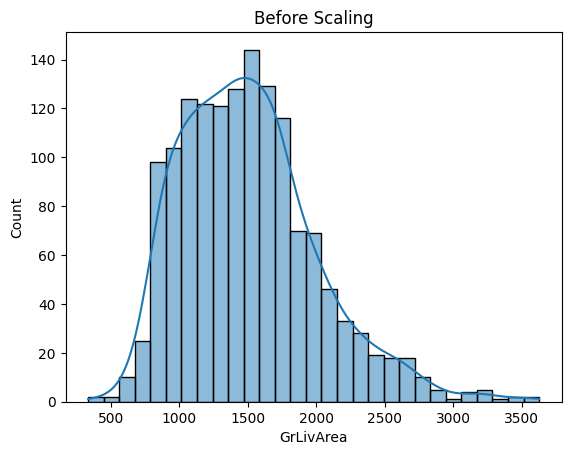

In [25]:
## Hour 7
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['GrLivArea'], kde=True)
plt.title("Before Scaling")
plt.show()

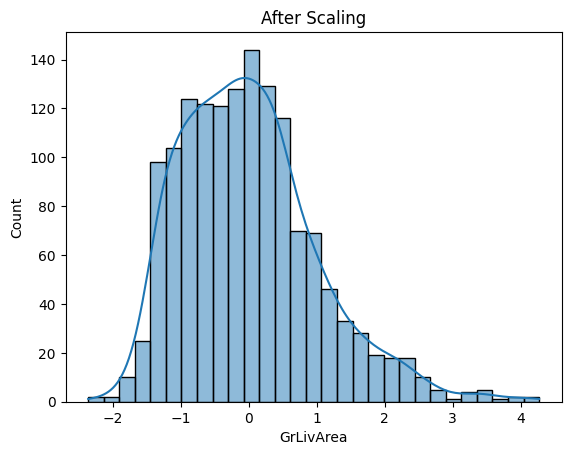

In [26]:
sns.histplot(X['GrLivArea'], kde=True)
plt.title("After Scaling")
plt.show()

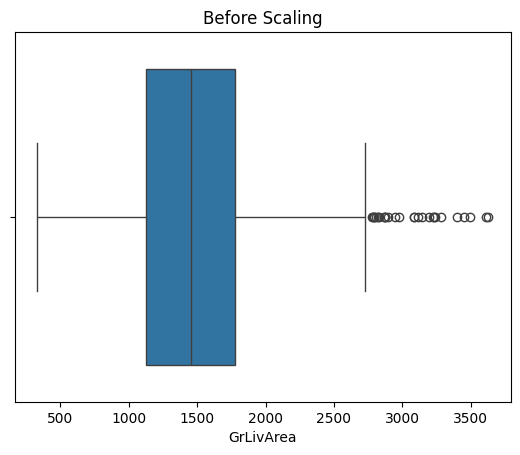

In [27]:
## Block 2
## Boxplot review
sns.boxplot(x=df['GrLivArea'])
plt.title("Before Scaling")
plt.show()

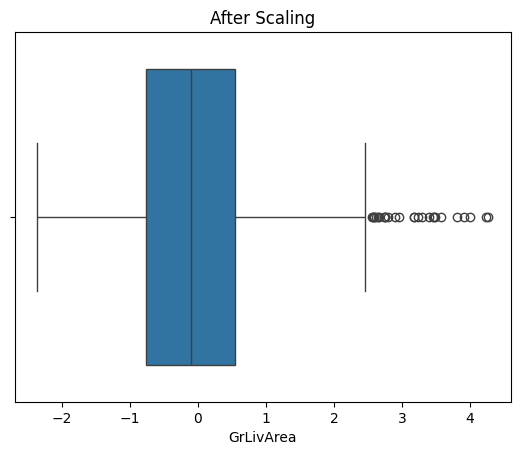

In [28]:
sns.boxplot(x=X['GrLivArea'])
plt.title("After Scaling")
plt.show()

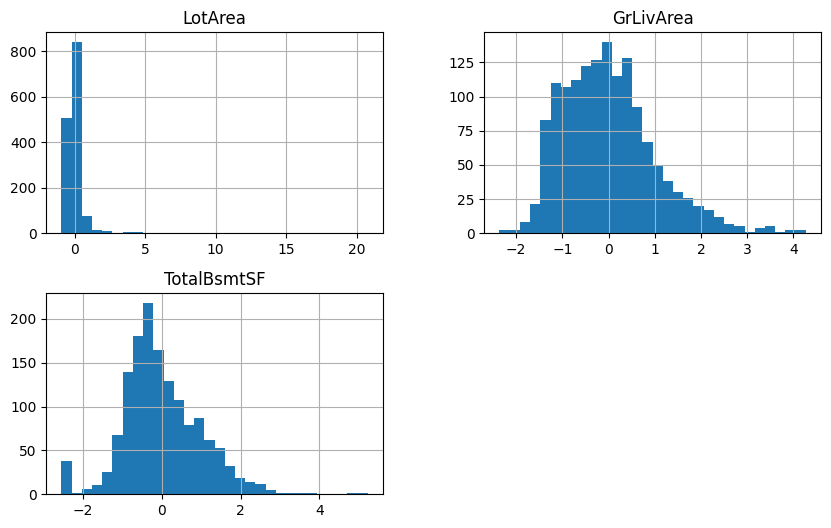

In [29]:
## Block 3
cols = ['LotArea','GrLivArea','TotalBsmtSF']

X[cols].hist(bins=30, figsize=(10,6))
plt.show()

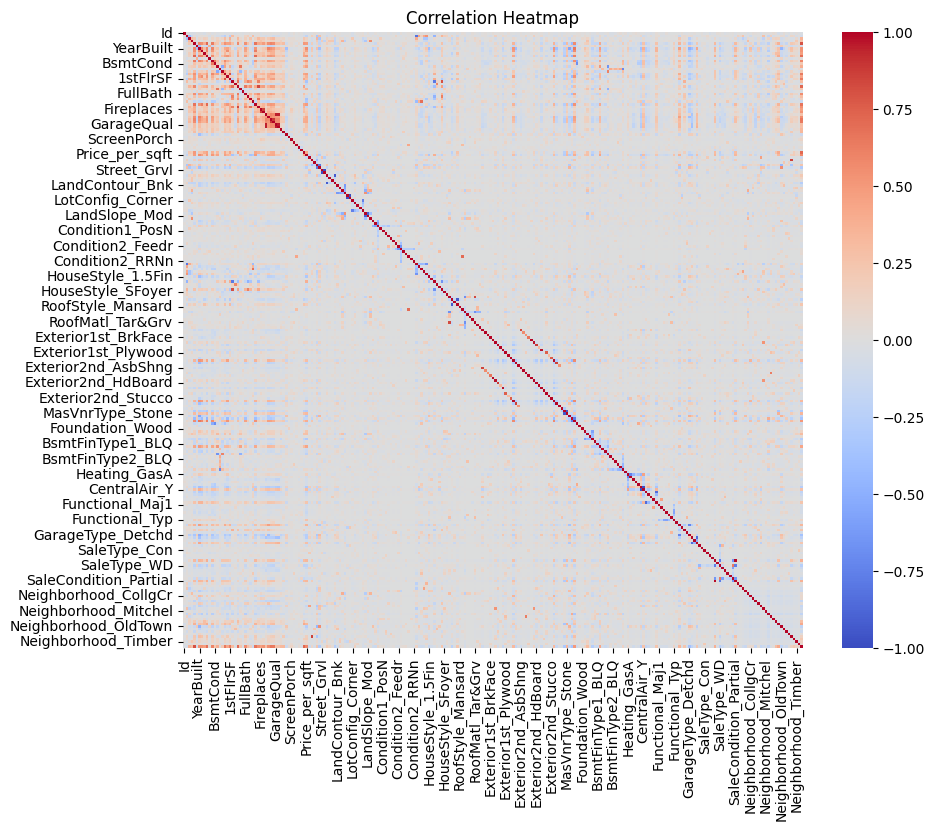

In [30]:
## Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_final.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [31]:
X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Id,1456.0,-7.808162e-17,1.000344,-1.729139,-0.866309,0.001264,0.864094,1.731667
MSSubClass,1456.0,2.318048e-17,1.000344,-0.871172,-0.871172,-0.162686,0.309638,3.143582
LotFrontage,1456.0,-1.903239e-16,1.000344,-2.293113,-0.464509,0.004363,0.473236,11.397969
LotArea,1456.0,5.368111e-17,1.000344,-0.928116,-0.295214,-0.099447,0.115570,20.775935
OverallQual,1456.0,-2.464451e-16,1.000344,-3.716479,-0.795063,-0.064709,0.665646,2.856708


In [32]:
## Hour 7
## Find the longest common prefix
Output="fl"
strs = ["flower","flow","flight"]
prefix = strs[0]
for s in strs[1:]:
    while not s.startswith(prefix):
        prefix = prefix[:-1]
print(prefix)

fl


In [33]:
## Hour 8

df_final.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,SalePrice
0,-1.729139,0.073476,-0.230073,-0.202770,0.665646,-0.517461,1.053769,0.880629,0.533895,1.066349,...,0,0,0,0,0,0,0,0,0,208500
1,-1.726767,-0.871172,0.473236,-0.086107,-0.064709,2.176545,0.159469,-0.427190,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,1,181500
2,-1.724395,0.073476,-0.089411,0.081281,0.665646,-0.517461,0.987524,0.832191,0.341751,1.066349,...,0,0,0,0,0,0,0,0,0,223500
3,-1.722023,0.309638,-0.464509,-0.091179,0.665646,-0.517461,-1.860986,-0.717817,-0.573757,-0.688006,...,0,0,0,0,0,0,0,0,0,140000
4,-1.719651,0.073476,0.660785,0.386636,1.396000,-0.517461,0.954402,0.735316,1.404192,1.066349,...,0,0,0,0,0,0,0,0,0,250000


In [ ]:
x=df_final.drop('SalePrice',axis=1)
y=df_final['SalePrice']



In [37]:
x.select_dtypes(include='object').columns
x.shape

(1456, 242)

In [38]:
## Final Sanity Check
print("Shape:", df_final.shape)
print("Missing:", df_final.isnull().sum().sum())
print("Object cols:", len(df_final.select_dtypes(include='object').columns))

Shape: (1456, 243)
Missing: 0
Object cols: 0
